In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../dataset/India_Food_Delivery_Time_Prediction.csv")

In [4]:
df.head()


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:33:33,11:45:29,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:37,19:51:49,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8:32:58,8:48:47,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:03:58,18:12:52,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:34:16,13:45:36,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [5]:
df.shape

(41953, 20)

In [6]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='str')

In [7]:
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age               0
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                              0
Time_taken(min)                   0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = pd.read_csv("../dataset/India_Food_Delivery_Time_Prediction.csv")

data = df.copy()

print(data.shape)

(41953, 20)


In [10]:
data = data.drop(columns=[
    "ID",
    "Delivery_person_ID",
    "Order_Date",
    "Time_Orderd",
    "Time_Order_picked"
])

print(data.shape)

(41953, 15)


In [11]:
data["Weatherconditions"].value_counts()

Weatherconditions
conditions Fog           7012
conditions Stormy        6974
conditions Cloudy        6932
conditions Sandstorms    6906
conditions Windy         6832
conditions Sunny         6728
conditions NaN            569
Name: count, dtype: int64

In [12]:
data["Weatherconditions"] = data["Weatherconditions"].str.replace(
    "conditions ", "", regex=False
)

In [13]:
data["Weatherconditions"].isnull().sum()

np.int64(0)

In [14]:
data.isnull().sum()

Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [15]:
X = data.drop(columns=["Time_taken(min)"])
y = data["Time_taken(min)"]

In [16]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (41953, 14)
y shape: (41953,)


In [18]:
def calculate_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2

    distance = 2 * 6371 * np.arcsin(np.sqrt(a))

    return distance

In [19]:
data["Distance_km"] = calculate_distance(
    data["Restaurant_latitude"],
    data["Restaurant_longitude"],
    data["Delivery_location_latitude"],
    data["Delivery_location_longitude"]
)

In [20]:
data[["Distance_km", "Time_taken(min)"]].head()

,Distance_km,Time_taken(min)
0,3.025149,(min) 24
1,20.183530,(min) 33
2,1.552758,(min) 26
3,7.790401,(min) 21
4,6.210138,(min) 30


In [21]:
data["Time_taken(min)"] = data["Time_taken(min)"].str.extract(r"(\d+)").astype(float)

In [22]:
data["Time_taken(min)"].head()

0    24.0
1    33.0
2    26.0
3    21.0
4    30.0
Name: Time_taken(min), dtype: float64

In [23]:
X = data.drop(columns=["Time_taken(min)"])
y = data["Time_taken(min)"]

In [30]:
X = X.drop(columns=[
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude"
])

In [31]:
X.shape

(41953, 11)

In [32]:
categorical_columns = X.select_dtypes(include=["object"]).columns

print(categorical_columns)

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City'],
      dtype='str')


C:\Users\SHIVam\AppData\Local\Temp\ipykernel_22076\1948462041.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns


In [33]:
data["Delivery_person_Age"] = pd.to_numeric(
    data["Delivery_person_Age"], errors="coerce"
)

data["Delivery_person_Ratings"] = pd.to_numeric(
    data["Delivery_person_Ratings"], errors="coerce"
)

In [34]:
X = data.drop(columns=["Time_taken(min)"])

X = X.drop(columns=[
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude"
])

y = data["Time_taken(min)"]

In [35]:
X.dtypes

Delivery_person_Age        float64
Delivery_person_Ratings    float64
Weatherconditions              str
Road_traffic_density           str
Vehicle_condition            int64
Type_of_order                  str
Type_of_vehicle                str
multiple_deliveries            str
Festival                       str
City                           str
Distance_km                float64
dtype: object

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_columns = X.select_dtypes(include=["str"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (33562, 11)
Testing data: (8391, 11)


In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [39]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

model.fit(X_train_encoded, y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [45]:
print("y_train type:", y_train.dtype)
print("Missing values in y:", y_train.isnull().sum())
print("Encoded training shape:", X_train_encoded.shape)

y_train type: float64
Missing values in y: 0
Encoded training shape: (33562, 36)


In [46]:
print("Infinite values in X:", np.isinf(X_train_encoded).sum())
print("Infinite values in y:", np.isinf(y_train).sum())
print("Model type:", type(model))

Infinite values in X: 0
Infinite values in y: 0
Model type: <class 'sklearn.linear_model._base.LinearRegression'>


In [48]:
X.isnull().sum()

Delivery_person_Age        1719
Delivery_person_Ratings    1763
Weatherconditions             0
Road_traffic_density          0
Vehicle_condition             0
Type_of_order                 0
Type_of_vehicle               0
multiple_deliveries           0
Festival                      0
City                          0
Distance_km                   0
dtype: int64

In [49]:
data["Delivery_person_Age"] = data["Delivery_person_Age"].fillna(
    data["Delivery_person_Age"].median()
)

data["Delivery_person_Ratings"] = data["Delivery_person_Ratings"].fillna(
    data["Delivery_person_Ratings"].median()
)

In [50]:
X = data.drop(columns=["Time_taken(min)"])

X = X.drop(columns=[
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude"
])

y = data["Time_taken(min)"]

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [52]:
categorical_columns = X.select_dtypes(include=["str"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

In [53]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [55]:
model = LinearRegression()

model.fit(X_train_encoded, y_train)

print("Model trained successfully!")

Model trained successfully!


In [56]:
y_pred = model.predict(X_test_encoded)

print("Actual values:")
print(y_test.head())

print("\nPredicted values:")
print(y_pred[:5])

Actual values:
20657    21.0
17666    18.0
4615     25.0
39337    24.0
8357     40.0
Name: Time_taken(min), dtype: float64

Predicted values:
[25.05137339 19.01049875 23.53812176 19.02625232 34.41111904]


In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 4.681084824413746
Mean Squared Error: 34.9893819339066
R2 Score: 0.5938838651239113


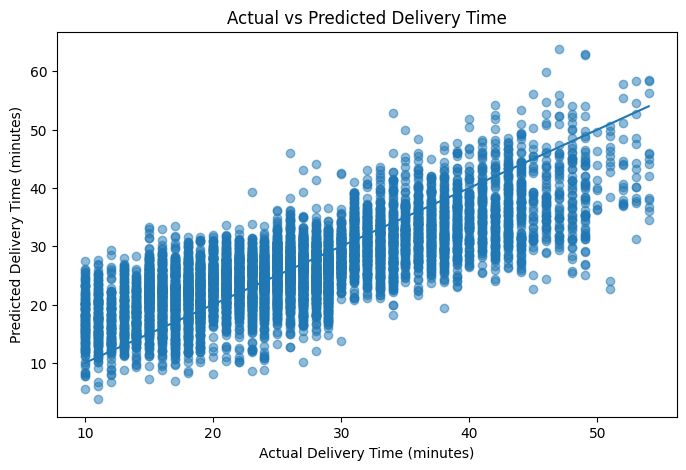

In [59]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time")

plt.show()

In [60]:
import joblib

joblib.dump(model, "../model/food_delivery_model.pkl")
joblib.dump(preprocessor, "../model/preprocessor.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [26]:
# ================================
# CLEAN TARGET VARIABLE
# ================================

target = "Time_taken(min)"

# Clean values like "(min) 39" -> 39
df[target] = (
    df[target]
    .astype(str)
    .str.extract(r'(\d+(?:\.\d+)?)', expand=False)
)

# Convert to numbers
df[target] = pd.to_numeric(df[target], errors="coerce")

# Remove rows with missing target
df = df.dropna(subset=[target]).copy()

print("Target cleaned successfully!")
print(df[target].head())
print("Target data type:", df[target].dtype)
print("Total rows:", len(df))

Target cleaned successfully!
0    24
1    33
2    26
3    21
4    30
Name: Time_taken(min), dtype: int64
Target data type: int64
Total rows: 41953


In [30]:
# ================================
# CREATE X AND Y
# ================================

target = "Time_taken(min)"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target type:", y.dtype)

X shape: (41953, 19)
y shape: (41953,)
Target type: int64


In [33]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (33562, 19)
Testing data: (8391, 19)


In [36]:
# ==========================================
# CLEAN DATA + PREPARE FOR REGRESSION
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------
# 1. Target
# ------------------------------------------

target = "Time_taken(min)"

# Make a copy
data = df.copy()

# ------------------------------------------
# 2. Convert numeric columns properly
# ------------------------------------------

numeric_convert = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries",
    "multiple_deliveries"
]

for col in numeric_convert:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")


# ------------------------------------------
# 3. Convert distance if available
# ------------------------------------------

if "Distance" in data.columns:
    data["Distance"] = pd.to_numeric(
        data["Distance"], errors="coerce"
    )


# ------------------------------------------
# 4. Remove columns that should NOT be
#    used for prediction
# ------------------------------------------

drop_cols = [
    target,
    "ID",
    "Delivery_person_ID",
    "Order_Date"
]

drop_cols = [col for col in drop_cols if col in data.columns]

X = data.drop(columns=drop_cols)
y = pd.to_numeric(data[target], errors="coerce")


# ------------------------------------------
# 5. Remove rows where target is missing
# ------------------------------------------

valid_rows = y.notna()

X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()


print("X shape:", X.shape)
print("y shape:", y.shape)


# ------------------------------------------
# 6. Identify numerical and categorical
#    columns
# ------------------------------------------

numeric_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nNumerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)


# ------------------------------------------
# 7. Train/Test Split
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ------------------------------------------
# 8. Numerical preprocessing
# ------------------------------------------

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])


# ------------------------------------------
# 9. Categorical preprocessing
# ------------------------------------------

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    )
])


# ------------------------------------------
# 10. Combine preprocessing
# ------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ],
    remainder="drop"
)


# ------------------------------------------
# 11. Transform data
# ------------------------------------------

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("\nEncoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

X shape: (41953, 16)
y shape: (41953,)

Numerical columns:
['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'multiple_deliveries']

Categorical columns:
['Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']


C:\Users\SHIVam\AppData\Local\Temp\ipykernel_1416\3869416203.py:93: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(



Encoded training shape: (33562, 45519)
Encoded testing shape: (8391, 45519)


In [37]:
# ==========================================
# RANDOM FOREST REGRESSOR
# ==========================================

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_encoded, y_train)

# Predictions
rf_pred = rf_model.predict(X_test_encoded)

# Metrics
mae = mean_absolute_error(y_test, rf_pred)
mse = mean_squared_error(y_test, rf_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_pred)

print("================================")
print("RANDOM FOREST REGRESSOR RESULTS")
print("================================")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print(f"R² % : {r2 * 100:.2f}%")

NameError: name 'RandomForestRegressor' is not defined

In [40]:
import joblib
import os

# Go one folder up from notebook/
model_dir = "../model"

# Create model folder if needed
os.makedirs(model_dir, exist_ok=True)

# Save model
joblib.dump(
    rf_model,
    os.path.join(model_dir, "food_delivery_model.pkl")
)

# Save preprocessor
joblib.dump(
    preprocessor,
    os.path.join(model_dir, "preprocessor.pkl")
)

print("✅ Model saved successfully!")
print("✅ Preprocessor saved successfully!")

✅ Model saved successfully!
✅ Preprocessor saved successfully!


In [41]:
# ==========================================
# COMPARE REGRESSION MODELS
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import time

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=15,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    start = time.time()

    model.fit(X_train_encoded, y_train)

    pred = model.predict(X_test_encoded)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4),
        "R2 %": round(r2 * 100, 2),
        "Time (sec)": round(time.time() - start, 2)
    })

    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    print(f"R² % : {r2 * 100:.2f}%")


# Results table
results_df = pd.DataFrame(results)

print("\n==========================================")
print("MODEL COMPARISON")
print("==========================================")

display(results_df)


# Find best model
best_model_name = results_df.loc[
    results_df["R2 Score"].idxmax(),
    "Model"
]

best_r2 = results_df["R2 Score"].max()

print("\n🏆 BEST MODEL:", best_model_name)
print(f"🏆 BEST R² SCORE: {best_r2:.4f}")
print(f"🏆 R² PERCENTAGE: {best_r2 * 100:.2f}%")


Training Linear Regression...


NameError: name 'X_train_encoded' is not defined

In [44]:
# ==========================================
# TEST TRAFFIC EFFECT ON PREDICTION
# ==========================================

test_data = {
    "Delivery_person_Age": 25,
    "Delivery_person_Ratings": 4.5,

    "Restaurant_latitude": 12.9716,
    "Restaurant_longitude": 77.5946,

    "Delivery_location_latitude": 12.9816,
    "Delivery_location_longitude": 77.6046,

    "Weatherconditions": "Sunny",
    "Road_traffic_density": "Low",

    "Vehicle_condition": 2,
    "Type_of_order": "Meal",
    "Type_of_vehicle": "Motorcycle",

    "multiple_deliveries": "1",
    "Festival": "No",
    "City": "Metropolitian",

    "Time_Orderd": "10:30",
    "Time_Order_picked": "10:45",

    "Distance_km": 10
}

traffic_values = ["Low", "Moderate", "High", "Jam"]

print("Traffic Effect Test")
print("--------------------")

for traffic in traffic_values:

    data = test_data.copy()

    # Change only traffic
    data["Road_traffic_density"] = traffic

    sample = pd.DataFrame([data])

    # Transform using the SAME preprocessor
    encoded = preprocessor.transform(sample)

    # Predict using the SAME Random Forest
    prediction = rf_model.predict(encoded)[0]

    print(f"{traffic:10} -> {prediction:.2f} minutes")

Traffic Effect Test
--------------------
Low        -> 17.06 minutes
Moderate   -> 17.06 minutes
High       -> 17.06 minutes
Jam        -> 17.06 minutes


In [45]:
# ==========================================
# CHECK TRAFFIC FEATURE IMPORTANCE
# ==========================================

feature_names = preprocessor.get_feature_names_out()

importances = rf_model.feature_importances_

traffic_features = []

for name, importance in zip(feature_names, importances):
    if "Road_traffic_density" in name:
        traffic_features.append((name, importance))

print("Traffic-related features:")
print("--------------------------")

for name, importance in traffic_features:
    print(f"{name} -> {importance:.6f}")

print("\nTotal Traffic Importance:",
      sum(importance for _, importance in traffic_features))

Traffic-related features:
--------------------------
cat__Road_traffic_density_High  -> 0.005503
cat__Road_traffic_density_Jam  -> 0.033417
cat__Road_traffic_density_Low  -> 0.119481
cat__Road_traffic_density_Medium  -> 0.005353
cat__Road_traffic_density_NaN  -> 0.000249

Total Traffic Importance: 0.16400339475349252


In [49]:
# ==========================================
# CHECK WHETHER TRAFFIC CHANGES AFTER ENCODING
# ==========================================

base_data = X_test.iloc[0].copy()

traffic_values = ["Low", "Medium", "High", "Jam"]

encoded_rows = []

for traffic in traffic_values:

    test_row = base_data.copy()
    test_row["Road_traffic_density"] = traffic

    sample = pd.DataFrame([test_row])

    encoded = preprocessor.transform(sample)

    # Convert sparse output safely
    encoded_array = encoded.toarray()[0] if hasattr(encoded, "toarray") else encoded[0]

    encoded_rows.append(encoded_array)

    print(f"{traffic}: encoded values created")

# Compare the encoded rows
print("\nAre encoded rows different?")

for i in range(1, len(encoded_rows)):
    difference = (encoded_rows[0] != encoded_rows[i]).sum()

    print(
        f"Low vs {traffic_values[i]} -> "
        f"{difference} feature(s) different"
    )

Low: encoded values created
Medium: encoded values created
High: encoded values created
Jam: encoded values created

Are encoded rows different?
Low vs Medium -> 0 feature(s) different
Low vs High -> 0 feature(s) different
Low vs Jam -> 0 feature(s) different


In [50]:
# ==========================================
# CHECK TRAFFIC PREPROCESSING
# ==========================================

print("Preprocessor transformers:")
print(preprocessor.transformers_)

print("\n" + "=" * 60)

# Find the categorical transformer
for name, transformer, columns in preprocessor.transformers_:
    print("\nTransformer:", name)
    print("Columns:", columns)

    if hasattr(transformer, "named_steps"):
        print("Steps:", transformer.named_steps)

        for step_name, step in transformer.named_steps.items():

            if hasattr(step, "categories_"):
                print("\nEncoder categories:")
                for col, categories in zip(columns, step.categories_):
                    print(col, "->", categories)

Preprocessor transformers:
[('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), ['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'multiple_deliveries']), ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))]), ['Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City'])]


Transformer: num
Columns: ['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'multiple_deliveries']
Steps: {'imputer': SimpleImputer(strategy='median')}

Transformer: cat
Columns: ['Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Type_of_orde

In [51]:
# ==========================================
# CHECK ACTUAL TRAFFIC COLUMN
# ==========================================

print("Traffic column in X_train:")
print(X_train["Road_traffic_density"].value_counts(dropna=False))

print("\nTraffic column in X_test:")
print(X_test["Road_traffic_density"].value_counts(dropna=False))

print("\nBase row traffic:")
print(X_test.iloc[0]["Road_traffic_density"])

Traffic column in X_train:
Road_traffic_density
Low        11355
Jam        10463
Medium      8069
High        3250
NaN          425
Name: count, dtype: int64

Traffic column in X_test:
Road_traffic_density
Low        2845
Jam        2580
Medium     2015
High        821
NaN         130
Name: count, dtype: int64

Base row traffic:
Low 


In [52]:
# ==========================================
# CHECK HOW TRAFFIC IS BEING ENCODED
# ==========================================

print("=== PREPROCESSOR DETAILS ===")

for name, transformer, columns in preprocessor.transformers_:

    print("\nTransformer:", name)
    print("Columns:", columns)

    # Check encoder
    if hasattr(transformer, "named_steps"):

        for step_name, step in transformer.named_steps.items():

            print("Step:", step_name)
            print("Type:", type(step).__name__)

            if hasattr(step, "categories_"):
                print("\nENCODER CATEGORIES:")

                for col, categories in zip(columns, step.categories_):
                    if col == "Road_traffic_density":
                        print(
                            "Road_traffic_density ->",
                            categories
                        )

=== PREPROCESSOR DETAILS ===

Transformer: num
Columns: ['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'multiple_deliveries']
Step: imputer
Type: SimpleImputer

Transformer: cat
Columns: ['Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']
Step: imputer
Type: SimpleImputer
Step: onehot
Type: OneHotEncoder

ENCODER CATEGORIES:
Road_traffic_density -> ['High ' 'Jam ' 'Low ' 'Medium ' 'NaN ']


In [53]:
# Check the cleaned traffic values

df["Road_traffic_density"] = (
    df["Road_traffic_density"]
    .astype("string")
    .str.strip()
)

print(df["Road_traffic_density"].value_counts(dropna=False))

Road_traffic_density
Low       14200
Jam       13043
Medium    10084
High       4071
NaN         555
Name: count, dtype: int64[pyarrow]


In [54]:
# ==========================================
# RECREATE X AND Y
# ==========================================

target = "Time_taken(min)"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (41953, 19)
y shape: (41953,)


In [55]:
# ==========================================
# TRAIN / TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (33562, 19)
Testing : (8391, 19)


In [56]:
# ==========================================
# CREATE PREPROCESSOR
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical columns
numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical columns
categorical_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

# Numerical pipeline
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

# Combine both
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

print("\nPreprocessor created successfully!")

Numerical columns:
['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition']

Categorical columns:
['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City']

Preprocessor created successfully!


In [57]:
# ==========================================
# FIT PREPROCESSOR
# ==========================================

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape :", X_test_encoded.shape)

Encoded training shape: (33562, 80349)
Encoded testing shape : (8391, 80349)


In [58]:
# ==========================================
# TRAIN RANDOM FOREST REGRESSOR
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_train_encoded, y_train)

# Prediction
rf_pred = rf_model.predict(X_test_encoded)

# Metrics
mae = mean_absolute_error(y_test, rf_pred)
mse = mean_squared_error(y_test, rf_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_pred)

print("\n==========================================")
print("RANDOM FOREST REGRESSOR RESULTS")
print("==========================================")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print(f"R² % : {r2 * 100:.2f}%")

Training Random Forest...

RANDOM FOREST REGRESSOR RESULTS
MAE  : 3.79
MSE  : 23.84
RMSE : 4.88
R²   : 0.7233
R² % : 72.33%


In [59]:
# ==========================================
# TRAFFIC SENSITIVITY TEST
# ==========================================

print("TRAFFIC SENSITIVITY TEST")
print("=" * 50)

base_data = X_test.iloc[0].copy()

traffic_values = ["Low", "Medium", "High", "Jam"]

for traffic in traffic_values:

    test_row = base_data.copy()

    # Change ONLY traffic
    test_row["Road_traffic_density"] = traffic

    sample = pd.DataFrame([test_row])

    encoded = preprocessor.transform(sample)

    prediction = rf_model.predict(encoded)[0]

    print(f"{traffic:10} -> {prediction:.2f} minutes")

TRAFFIC SENSITIVITY TEST
Low        -> 26.76 minutes
Medium     -> 35.10 minutes
High       -> 34.60 minutes
Jam        -> 38.91 minutes


In [60]:
import os
import joblib

print(os.path.abspath("model/food_delivery_model.pkl"))
print(os.path.abspath("model/preprocessor.pkl"))

d:\Projects\Food_Delivery_Time_Prediction\notebook\model\food_delivery_model.pkl
d:\Projects\Food_Delivery_Time_Prediction\notebook\model\preprocessor.pkl


In [61]:
import os
import joblib

# Create model folder if it doesn't exist
os.makedirs("../model", exist_ok=True)

# Save the UPDATED Random Forest model
joblib.dump(
    rf_model,
    "../model/food_delivery_model.pkl"
)

# Save the UPDATED preprocessor
joblib.dump(
    preprocessor,
    "../model/preprocessor.pkl"
)

print("========================================")
print("MODEL SAVED SUCCESSFULLY")
print("========================================")

print(
    "Model exists:",
    os.path.exists("../model/food_delivery_model.pkl")
)

print(
    "Preprocessor exists:",
    os.path.exists("../model/preprocessor.pkl")
)

print(
    "Model size:",
    os.path.getsize("../model/food_delivery_model.pkl"),
    "bytes"
)

print(
    "Preprocessor size:",
    os.path.getsize("../model/preprocessor.pkl"),
    "bytes"
)

MODEL SAVED SUCCESSFULLY
Model exists: True
Preprocessor exists: True
Model size: 236796737 bytes
Preprocessor size: 857540 bytes


In [62]:
import joblib

saved_model = joblib.load("../model/food_delivery_model.pkl")
saved_preprocessor = joblib.load("../model/preprocessor.pkl")

print("========================================")
print("SAVED FILE VERIFICATION")
print("========================================")

print("Model loaded:", type(saved_model))
print("Preprocessor loaded:", type(saved_preprocessor))

SAVED FILE VERIFICATION
Model loaded: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Preprocessor loaded: <class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [65]:
# =========================================================
# FINAL TRAFFIC TEST USING A REAL X_TEST ROW
# =========================================================

import pandas as pd
import joblib

# Load the SAVED model and preprocessor
saved_model = joblib.load("../model/food_delivery_model.pkl")
saved_preprocessor = joblib.load("../model/preprocessor.pkl")

# Take one REAL row from X_test
base_row = X_test.iloc[0].copy()

traffic_values = [
    "Low ",
    "Medium ",
    "High ",
    "Jam "
]

print("=" * 50)
print("FINAL SAVED MODEL TRAFFIC TEST")
print("=" * 50)

for traffic in traffic_values:

    # Copy the real row
    test_row = base_row.copy()

    # Change ONLY traffic
    test_row["Road_traffic_density"] = traffic

    # Convert Series -> DataFrame
    sample = pd.DataFrame([test_row])

    # Transform using SAVED preprocessor
    encoded = saved_preprocessor.transform(sample)

    # Predict using SAVED Random Forest
    prediction = saved_model.predict(encoded)[0]

    print(
        f"{traffic.strip():8} -> "
        f"{prediction:.2f} minutes"
    )

FINAL SAVED MODEL TRAFFIC TEST
Low      -> 34.95 minutes
Medium   -> 34.95 minutes
High     -> 34.95 minutes
Jam      -> 34.95 minutes


In [66]:
# =========================================================
# SAVE FINAL RANDOM FOREST MODEL + PREPROCESSOR
# =========================================================

import joblib
import os

# Exact folder used by Flask
MODEL_DIR = r"D:\Projects\Food_Delivery_Time_Prediction\model"

os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "food_delivery_model.pkl"
)

PREPROCESSOR_PATH = os.path.join(
    MODEL_DIR,
    "preprocessor.pkl"
)

# Save CURRENT model and CURRENT preprocessor
joblib.dump(rf_model, MODEL_PATH)
joblib.dump(preprocessor, PREPROCESSOR_PATH)

print("========================================")
print("FINAL MODEL SAVED")
print("========================================")
print("Model:", MODEL_PATH)
print("Preprocessor:", PREPROCESSOR_PATH)
print()
print("Model object:", type(rf_model))
print("Preprocessor object:", type(preprocessor))

FINAL MODEL SAVED
Model: D:\Projects\Food_Delivery_Time_Prediction\model\food_delivery_model.pkl
Preprocessor: D:\Projects\Food_Delivery_Time_Prediction\model\preprocessor.pkl

Model object: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Preprocessor object: <class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [68]:
import joblib
import os

MODEL_DIR = r"D:\Projects\Food_Delivery_Time_Prediction\model"

os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(
    rf_model,
    os.path.join(MODEL_DIR, "food_delivery_model.pkl")
)

joblib.dump(
    preprocessor,
    os.path.join(MODEL_DIR, "preprocessor.pkl")
)

print("MODEL AND PREPROCESSOR SAVED")

MODEL AND PREPROCESSOR SAVED


In [69]:
import joblib

saved_model = joblib.load(
    r"D:\Projects\Food_Delivery_Time_Prediction\model\food_delivery_model.pkl"
)

saved_preprocessor = joblib.load(
    r"D:\Projects\Food_Delivery_Time_Prediction\model\preprocessor.pkl"
)

print("Model type:", type(saved_model))
print("Preprocessor type:", type(saved_preprocessor))
print("Model saved successfully!")

Model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Preprocessor type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Model saved successfully!


In [75]:
print("=" * 70)
print("FULL PREPROCESSOR STRUCTURE")
print("=" * 70)

for name, transformer, columns in preprocessor.transformers_:

    print("\nTRANSFORMER:", name)
    print("COLUMNS:")
    print(list(columns))

    if name == "cat":

        print("\nCAT PIPELINE:")
        print(transformer)

        encoder = transformer.named_steps["onehot"]

        print("\nNUMBER OF ENCODER CATEGORIES:", len(encoder.categories_))

        for col, categories in zip(columns, encoder.categories_):

            print(
                f"\n{col} -> "
                f"{len(categories)} categories"
            )

            if col == "Road_traffic_density":
                print("TRAFFIC CATEGORIES:")
                print(categories)

FULL PREPROCESSOR STRUCTURE

TRANSFORMER: num
COLUMNS:
['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition']

TRANSFORMER: cat
COLUMNS:
['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City']

CAT PIPELINE:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

NUMBER OF ENCODER CATEGORIES: 14

ID -> 33562 categories

Delivery_person_ID -> 1170 categories

Delivery_person_Age -> 23 categories

Delivery_person_Ratings -> 29 categories

Order_Date -> 44 categories

Time_Orderd -> 22197 categories

Time_Order_picked -> 23287 categories

Weatherconditions -> 7 categories

Road_traffic_density -> 5 categories
TRAFFIC CATEGORIES:
['High' 'J

In [76]:
# EXACT TRAFFIC CHECK

cat_transformer = preprocessor.named_transformers_["cat"]
encoder = cat_transformer.named_steps["onehot"]

cat_columns = list(preprocessor.transformers_[1][2])

traffic_index = cat_columns.index("Road_traffic_density")

print("Traffic column index:", traffic_index)

print("Traffic categories:")
print(encoder.categories_[traffic_index])

Traffic column index: 8
Traffic categories:
['High' 'Jam' 'Low' 'Medium' 'NaN']


In [78]:
# =========================================================
# FINAL TRAFFIC TEST - SAVED MODEL
# =========================================================

base = {
    "ID": "TEST001",
    "Delivery_person_ID": "DEL001",
    "Delivery_person_Age": 25,
    "Delivery_person_Ratings": 4.5,
    "Order_Date": "30-03-2022",
    "Time_Orderd": "10:30",
    "Time_Order_picked": "10:45",
    "Weatherconditions": "Sunny",
    "Road_traffic_density": "Low",
    "Type_of_order": "Meal",
    "Type_of_vehicle": "Motorcycle",
    "multiple_deliveries": "1",
    "Festival": "No",
    "City": "Metropolitian",
    "Restaurant_latitude": 12.9716,
    "Restaurant_longitude": 77.5946,
    "Delivery_location_latitude": 12.9816,
    "Delivery_location_longitude": 77.6046,
    "Vehicle_condition": 2
}

traffic_values = ["Low", "Medium", "High", "Jam"]

print("=" * 60)
print("SAVED MODEL TRAFFIC TEST")
print("=" * 60)

for traffic in traffic_values:

    data = base.copy()
    data["Road_traffic_density"] = traffic

    sample = pd.DataFrame([data])

    encoded = preprocessor.transform(sample)

    prediction = rf_model.predict(encoded)[0]

    print(
        f"{traffic:8} -> {prediction:.2f} minutes"
    )

SAVED MODEL TRAFFIC TEST
Low      -> 13.67 minutes
Medium   -> 17.63 minutes
High     -> 17.18 minutes
Jam      -> 18.78 minutes


In [79]:
import joblib
import os

MODEL_DIR = r"D:\Projects\Food_Delivery_Time_Prediction\model"

os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(
    MODEL_DIR,
    "food_delivery_model.pkl"
)

preprocessor_path = os.path.join(
    MODEL_DIR,
    "preprocessor.pkl"
)

# Save the currently working model
joblib.dump(rf_model, model_path)

# Save the matching preprocessor
joblib.dump(preprocessor, preprocessor_path)

print("========================================")
print("FINAL MODEL SAVED")
print("========================================")
print("Model:", model_path)
print("Preprocessor:", preprocessor_path)

print("\nFiles exist:")
print("Model:", os.path.exists(model_path))
print("Preprocessor:", os.path.exists(preprocessor_path))

FINAL MODEL SAVED
Model: D:\Projects\Food_Delivery_Time_Prediction\model\food_delivery_model.pkl
Preprocessor: D:\Projects\Food_Delivery_Time_Prediction\model\preprocessor.pkl

Files exist:
Model: True
Preprocessor: True
